In [1004]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [1005]:
data = pd.read_csv("data1.csv")
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64810 entries, 0 to 64809
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0.1      64810 non-null  int64  
 1   Unnamed: 0        64810 non-null  int64  
 2   id                64810 non-null  object 
 3   connectionTime    64810 non-null  object 
 4   disconnectTime    64810 non-null  object 
 5   doneChargingTime  60729 non-null  object 
 6   kWhDelivered      64810 non-null  float64
 7   sessionID         64810 non-null  object 
 8   siteID            64810 non-null  int64  
 9   spaceID           64810 non-null  object 
 10  stationID         64810 non-null  object 
 11  timezone          64810 non-null  object 
 12  userID            47635 non-null  float64
 13  userInputs        47635 non-null  object 
 14  next_connection   64703 non-null  object 
 15  next_disconnect   64703 non-null  object 
dtypes: float64(2), int64(3), object(11)
memo

## Data Preparation for clustering

First we want to drop all the features in our dataset which are of no relevance for our clustering. Furthermore we drop all datapoints of unregistered user, since we are going to analyse the behavior of registered users.

In [1006]:
data = data.drop(["next_connection", "next_disconnect", "Unnamed: 0.1", "Unnamed: 0", "id"], axis=1)
data_reg = data.dropna(subset=["userID", "doneChargingTime"])


In [1007]:
# space und station scheint das gleiche zu sein

print(data_reg["spaceID"].nunique())
print(data_reg["stationID"].nunique())
(data_reg.groupby("spaceID")["stationID"].nunique() == 1).all()

105
105


np.True_

In [1008]:
date_columns = ["connectionTime", "disconnectTime", "doneChargingTime"]

for data in date_columns:
    data_reg[data] = pd.to_datetime(data_reg[data])

def convert_to_local(row): 
    tz = row["timezone"]
    for col in date_columns:
        ts = row[col]
        if pd.isna(ts):
            continue 
        row[col] = ts.tz_convert(tz)
    return row 

data_reg = data_reg.apply(convert_to_local, axis=1)

data_reg.info()

<class 'pandas.core.frame.DataFrame'>
Index: 44462 entries, 0 to 64809
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype                              
---  ------            --------------  -----                              
 0   connectionTime    44462 non-null  datetime64[ns, America/Los_Angeles]
 1   disconnectTime    44462 non-null  datetime64[ns, America/Los_Angeles]
 2   doneChargingTime  44462 non-null  datetime64[ns, America/Los_Angeles]
 3   kWhDelivered      44462 non-null  float64                            
 4   sessionID         44462 non-null  object                             
 5   siteID            44462 non-null  int64                              
 6   spaceID           44462 non-null  object                             
 7   stationID         44462 non-null  object                             
 8   timezone          44462 non-null  object                             
 9   userID            44462 non-null  float64                         

## Preparing relevant features

In order to describe user behavior, we want to analyse the time of connection and the duration. 
- **charging duration**: We calculate the duration of charging from the features "doneChargingTime" and "connectionTime".
- **blocking charging**: We look at the duration when the car is done charging and still connected to the station, as it shows typical user behavior.
- **connection hour**: We extract the hour of the day from the variable "connectionTime". Since the hour of connection is cyclical, we cannot use it as an integer when we cluster. The hours 23 and 00 have a very large distance (23), eventhough they are very close. That is why we represent the time of connection by two variables hour_sin and hour_cos.
- **weekday**: We extract the day of the week from the variable "connectionTime" and devide the days of the week into two categories (weekday and weekend). As before we can drop the second category, since it is implicity defined by the first one.

In [1009]:
data_reg["blocking_duration_min"] = ((data_reg["disconnectTime"] - data_reg["doneChargingTime"]).dt.total_seconds()/60).round()
data_reg["charging_duration_min"] = ((data_reg["doneChargingTime"] - data_reg["connectionTime"]).dt.total_seconds()/60).round()

data_reg["connection_hour"] = data_reg["connectionTime"].dt.hour
data_reg["con_hour_sin"] = np.sin(2 * np.pi * data_reg["connection_hour"] / 24)
data_reg["con_hour_cos"] = np.cos(2 * np.pi * data_reg["connection_hour"] / 24)

data_reg["weekday"] = data_reg["connectionTime"].dt.dayofweek
data_reg["is_weekday"] = data_reg["weekday"] < 5


We convert the feature "siteID" into a boolean feature for siteID = 1. We do not need a second feature for siteID = 2, as it is implicity described by the first feature.

In [1010]:
data_reg["siteOne"] = (data_reg["siteID"] == 1)

 ### Handling of the User Inputs

We convert our userInputs and delete all rows where the userInputs have multiple lists.

In [1011]:
import ast
data_reg['userInputs'] = data_reg['userInputs'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

In [1012]:
data_reg['n_userInputs'] = data_reg['userInputs'].apply(len)
data_reg = data_reg[data_reg["n_userInputs"] < 2]
data_reg.head(10)

,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,spaceID,stationID,timezone,userID,userInputs,blocking_duration_min,charging_duration_min,connection_hour,con_hour_sin,con_hour_cos,weekday,is_weekday,siteOne,n_userInputs
0,2020-01-02 05:08:54-08:00,2020-01-02 11:11:15-08:00,2020-01-02 09:31:35-08:00,25.016,1_1_179_810_2020-01-02 13:08:53.870034,1,AG-3F30,1-1-179-810,America/Los_Angeles,194.0,"[{'WhPerMile': 250, 'kWhRequested': 25.0, 'milesRequested': 100, 'minutesAvailable': 463, 'modifiedAt': 'Thu, 02 Jan 2020 13:09:39 GMT', 'paymentRequired': True, 'requestedDeparture': 'Thu, 02 Jan 2020 20:51:54 GMT', 'userID': 194}]",100.0,263.0,5,0.965926,2.588190e-01,3,True,True,1
1,2020-01-02 05:36:50-08:00,2020-01-02 14:38:21-08:00,2020-01-02 12:18:05-08:00,33.097,1_1_193_825_2020-01-02 13:36:49.599853,1,AG-1F01,1-1-193-825,America/Los_Angeles,4275.0,"[{'WhPerMile': 280, 'kWhRequested': 70.0, 'milesRequested': 250, 'minutesAvailable': 595, 'modifiedAt': 'Thu, 02 Jan 2020 13:37:11 GMT', 'paymentRequired': True, 'requestedDeparture': 'Thu, 02 Jan 2020 23:31:50 GMT', 'userID': 4275}]",140.0,401.0,5,0.965926,2.588190e-01,3,True,True,1
2,2020-01-02 05:56:35-08:00,2020-01-02 16:39:22-08:00,2020-01-02 08:35:06-08:00,6.521,1_1_193_829_2020-01-02 13:56:35.214993,1,AG-1F03,1-1-193-829,America/Los_Angeles,344.0,"[{'WhPerMile': 400, 'kWhRequested': 8.0, 'milesRequested': 20, 'minutesAvailable': 60, 'modifiedAt': 'Thu, 02 Jan 2020 13:57:17 GMT', 'paymentRequired': True, 'requestedDeparture': 'Thu, 02 Jan 2020 14:56:35 GMT', 'userID': 344}]",484.0,159.0,5,0.965926,2.588190e-01,3,True,True,1
4,2020-01-02 06:00:01-08:00,2020-01-02 14:08:40-08:00,2020-01-02 10:17:30-08:00,13.375,1_1_193_819_2020-01-02 14:00:00.779967,1,AG-1F06,1-1-193-819,America/Los_Angeles,334.0,"[{'WhPerMile': 400, 'kWhRequested': 16.0, 'milesRequested': 40, 'minutesAvailable': 504, 'modifiedAt': 'Thu, 02 Jan 2020 14:00:13 GMT', 'paymentRequired': True, 'requestedDeparture': 'Thu, 02 Jan 2020 22:24:01 GMT', 'userID': 334}]",231.0,257.0,6,1.000000,6.123234e-17,3,True,True,1
5,2020-01-02 06:00:13-08:00,2020-01-02 15:00:41-08:00,2020-01-02 12:13:21-08:00,13.370,1_1_194_821_2020-01-02 14:00:05.241573,1,AG-1F13,1-1-194-821,America/Los_Angeles,3519.0,"[{'WhPerMile': 600, 'kWhRequested': 24.0, 'milesRequested': 40, 'minutesAvailable': 624, 'modifiedAt': 'Thu, 02 Jan 2020 14:00:12 GMT', 'paymentRequired': True, 'requestedDeparture': 'Fri, 03 Jan 2020 00:24:13 GMT', 'userID': 3519}]",167.0,373.0,6,1.000000,6.123234e-17,3,True,True,1
6,2020-01-02 06:09:14-08:00,2020-01-02 17:57:58-08:00,2020-01-02 16:59:21-08:00,43.477,1_1_178_817_2020-01-02 14:09:14.451827,1,AG-1F09,1-1-178-817,America/Los_Angeles,933.0,"[{'WhPerMile': 385, 'kWhRequested': 65.45, 'milesRequested': 170, 'minutesAvailable': 647, 'modifiedAt': 'Thu, 02 Jan 2020 14:09:33 GMT', 'paymentRequired': True, 'requestedDeparture': 'Fri, 03 Jan 2020 00:56:14 GMT', 'userID': 933}]",59.0,650.0,6,1.000000,6.123234e-17,3,True,True,1
7,2020-01-02 06:17:32-08:00,2020-01-02 16:44:54-08:00,2020-01-02 12:22:40-08:00,32.441,1_1_191_804_2020-01-02 14:17:32.329535,1,AG-4F34,1-1-191-804,America/Los_Angeles,3737.0,"[{'WhPerMile': 300, 'kWhRequested': 45.0, 'milesRequested': 150, 'minutesAvailable': 126, 'modifiedAt': 'Thu, 02 Jan 2020 14:17:40 GMT', 'paymentRequired': True, 'requestedDeparture': 'Thu, 02 Jan 2020 16:23:32 GMT', 'userID': 3737}]",262.0,365.0,6,1.000000,6.123234e-17,3,True,True,1
8,2020-01-02 06:25:38-08:00,2020-01-02 11:36:05-08:00,2020-01-02 10:38:39-08:00,13.264,1_1_194_826_2020-01-02 14:25:37.578692,1,AG-1F11,1-1-194-826,America/Los_Angeles,419.0,"[{'WhPerMile': 400, 'kWhRequested': 40.0, 'milesRequested': 100, 'minutesAvailable': 491, 'modifiedAt': 'Thu, 02 Jan 2020 14:25:45 GMT', 'paymentRequired': True, 'requestedDeparture': 'Thu, 02 Jan 2020 22:36:38 GMT', 'userID': 419}]",57.0,253.0,6,1.000000,6.123234e-17,3,True,True,1
9,2020-01-02 06:27:40-08:00,2020-01-02 12:01:48-08:00,2020-01-02 11:17:46-08:00,

In [1013]:
#pd.set_option("display.max_colwidth", None)

Payment Required always true, so unimportant

In [1014]:
data_reg['userInputs'] = data_reg['userInputs'].apply(
    lambda x: x[0] if isinstance(x, list) and len(x) == 1 else {}
)

keys = [
    'WhPerMile',
    'kWhRequested',
    'minutesAvailable',
    'milesRequested'
]

for k in keys:
    data_reg[k] = data_reg['userInputs'].apply(lambda d: d.get(k))


### Handling outliers

In [1015]:
import seaborn as sns
import matplotlib.pyplot as plt

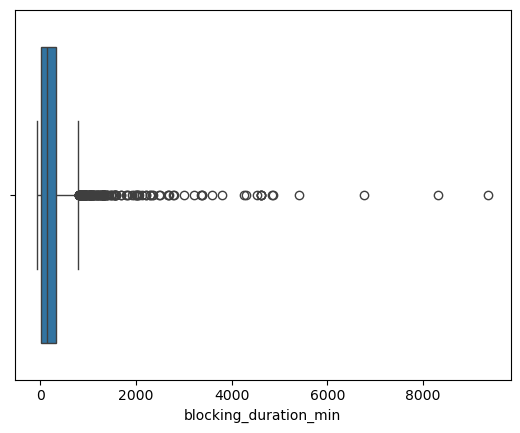

In [1016]:
sns.boxplot(x=data_reg["blocking_duration_min"])
plt.show()

In [1017]:
def iqr_outliers(series, lower_k, upper_k):
    Q1 = series.quantile(0.15)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - lower_k * IQR
    upper = Q3 + upper_k * IQR
    return lower, upper

lowerkWh, upperkWh = iqr_outliers(
    data_reg["kWhDelivered"], 
    lower_k=1.5, upper_k=5.0
    )

lowerc, upperc = iqr_outliers(
    data_reg["charging_duration_min"], 
    lower_k=1.5, upper_k=6.0
    )

lowerb, upperb = iqr_outliers(
    data_reg["blocking_duration_min"], 
    lower_k=1.5, upper_k=8.0
    )

data_reg = data_reg[
    (data_reg["kWhDelivered"] >= lowerkWh) &
    (data_reg["kWhDelivered"] <= upperkWh) &
    (data_reg["charging_duration_min"] >= lowerc) &
    (data_reg["charging_duration_min"] <= upperc) &
    (data_reg["blocking_duration_min"] >= lowerb) &
    (data_reg["blocking_duration_min"] <= upperb)
]
#sns.boxplot(x=data_reg["blocking_duration_min"])
#plt.show()


In [1018]:
data_reg["kWhrequest_difference"] = data_reg["kWhRequested"] - data_reg["kWhDelivered"]
data_reg["kWhrequest_ratio"] = data_reg["kWhDelivered"]/(data_reg["kWhRequested"]+1)
print(data_reg["kWhrequest_difference"].min())
print(data_reg["kWhrequest_difference"].max())

-39.076
213.686


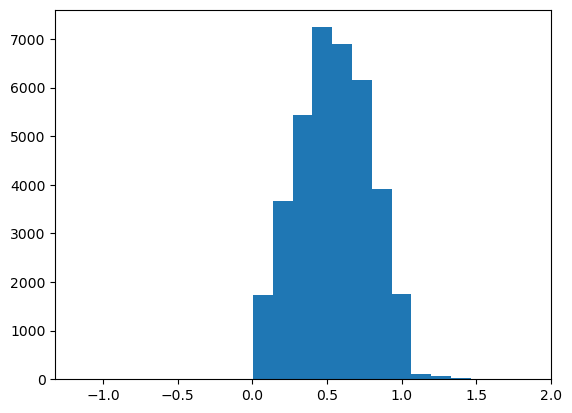

In [1019]:
plt.hist(data_reg["kWhrequest_ratio"], bins=200)
plt.xlim(right=2)
plt.show()

## Create User Dataframe


In [1020]:
user_df = (
    data_reg
    .groupby("userID")
    .agg(
        n_sessions=("sessionID", "count"),

        first_session=("connectionTime", "min"),
        last_session=("connectionTime", "max"),
        
        avg_charging_time=("charging_duration_min", "mean"),
        avg_blocking_time=("blocking_duration_min", "mean"),
        weekday_ratio=("is_weekday", "mean"),
        
        avg_kWh=("kWhDelivered", "mean"),
        
        site_one_ratio=("siteOne", "mean"),

        avg_connection_hour_sin=("con_hour_sin", "mean"),
        avg_connection_hour_cos=("con_hour_cos", "mean"),
        
        avg_wh_per_mile=("WhPerMile", "mean"),
        avg_minutes_available=("minutesAvailable", "mean"),
        avg_kWh_requested=("kWhRequested", "mean")
    )
    .reset_index()
)

In [1021]:
observation_start = data_reg['connectionTime'].min()
observation_end = data_reg["connectionTime"].max()
observation_span_weeks = (observation_end - observation_start).total_seconds()/(60*60*24*7)

user_df["active_weeks"] = (user_df["last_session"]-user_df["first_session"]).dt.total_seconds()/(60*60*24*7) + 1
user_df["active_weeks_ratio"] = user_df["active_weeks"] / observation_span_weeks
user_df["sessions_per_week"] = user_df["n_sessions"] / user_df["active_weeks"]
user_df
print(observation_start)
print(observation_end)
print(observation_span_weeks)

user_df["is_single_user"] = user_df["n_sessions"] == 1
user_df.head(5)

2018-04-30 08:07:49-07:00
2021-09-13 12:53:30-07:00
176.0283416005291


,userID,n_sessions,first_session,last_session,avg_charging_time,avg_blocking_time,weekday_ratio,avg_kWh,site_one_ratio,avg_connection_hour_sin,avg_connection_hour_cos,avg_wh_per_mile,avg_minutes_available,avg_kWh_requested,active_weeks,active_weeks_ratio,sessions_per_week,is_single_user
0,1.0,1,2018-06-22 13:11:23-07:00,2018-06-22 13:11:23-07:00,74.000000,10.000000,1.00,1.659000,0.0,-0.258819,-0.965926,500.000000,150.000000,5.00000,1.000000,0.005681,1.000000,True
1,22.0,47,2018-04-30 08:07:49-07:00,2020-01-13 12:51:37-08:00,255.851064,143.382979,1.00,19.137211,0.0,0.610461,-0.619514,353.191489,469.765957,37.67766,90.034107,0.511475,0.522024,False
2,43.0,1,2018-08-11 09:12:38-07:00,2018-08-11 09:12:38-07:00,419.000000,78.000000,0.00,43.266000,0.0,0.707107,-0.707107,217.000000,469.000000,43.40000,1.000000,0.005681,1.000000,True
3,45.0,1,2018-09-16 17:00:47-07:00,2018-09-16 17:00:47-07:00,129.000000,84.000000,0.00,8.069000,0.0,-0.965926,-0.258819,250.000000,134.000000,17.50000,1.000000,0.005681,1.000000,True
4,58.0,4,2018-08-19 17:11:25-07:00,2018-10-21 11:11:39-07:00,308.250000,74.250000,0.25,33.903750,0.0,-0.634765,-0.245891,300.000000,601.500000,83.25000,9.964309,0.056606,0.401433,False


## Analyse correlations

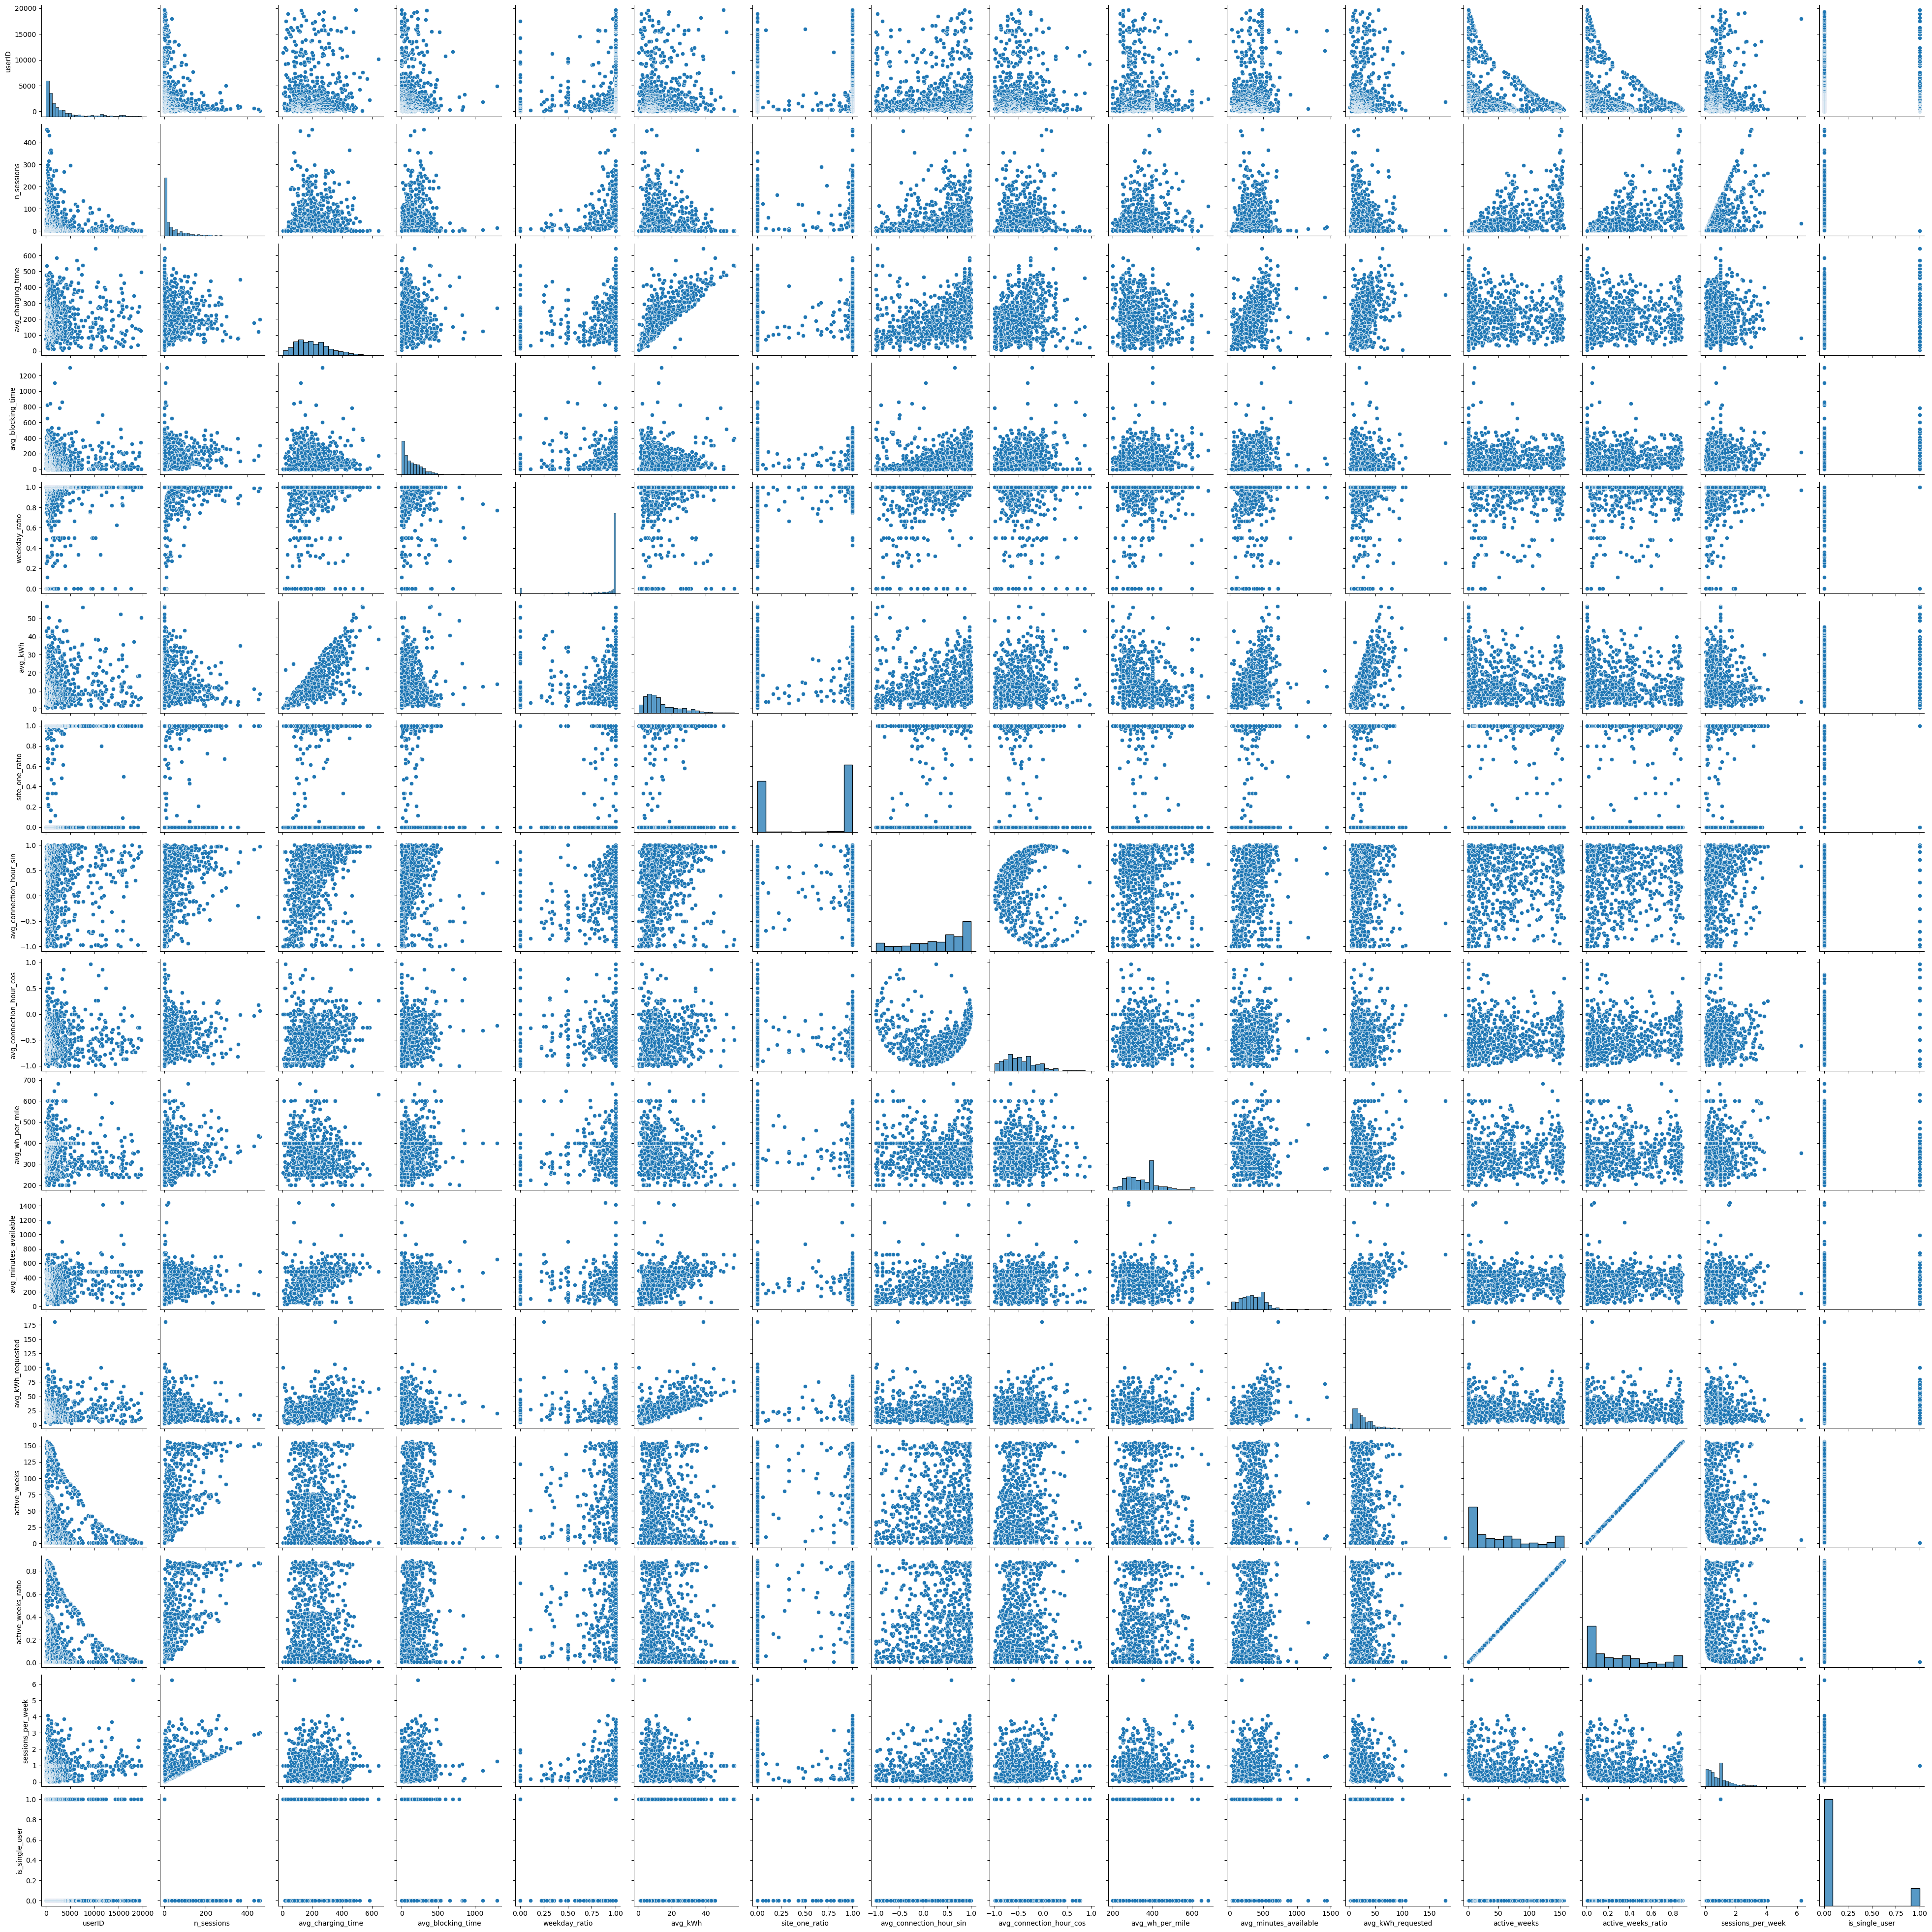

In [1022]:
sns.pairplot(user_df)
plt.show()

In [1023]:
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from skfda.ml.clustering import FuzzyCMeans
from matplotlib.lines import Line2D
from sklearn.metrics import silhouette_samples, silhouette_score
%matplotlib inline

### Dropping irrelevant or less relevant features

To avaid the curse of dimensinality, we want to keep only the most valuable features. Firstly we can drop "userID", "n_sessions", "first_session", "last_session" and "active_weeks". We look at the correlations between features, their distributions and their logical significance, to determine which features to keep.

In [1039]:
# dropping avg wh per mile and avg kWh, because it doesnt seem to have any relevance
X = user_df.drop(["userID","n_sessions","first_session", "last_session", "active_weeks", "avg_wh_per_mile", "avg_minutes_available", "avg_kWh", "avg_kWh_requested", "active_weeks_ratio"], axis=1)
X

,avg_charging_time,avg_blocking_time,weekday_ratio,site_one_ratio,avg_connection_hour_sin,avg_connection_hour_cos,sessions_per_week,is_single_user
0,74.000000,10.000000,1.00,0.0,-0.258819,-0.965926,1.000000,True
1,255.851064,143.382979,1.00,0.0,0.610461,-0.619514,0.522024,False
2,419.000000,78.000000,0.00,0.0,0.707107,-0.707107,1.000000,True
3,129.000000,84.000000,0.00,0.0,-0.965926,-0.258819,1.000000,True
4,308.250000,74.250000,0.25,0.0,-0.634765,-0.245891,0.401433,False
...,...,...,...,...,...,...,...,...
792,37.000000,0.000000,1.00,0.0,-0.965926,-0.258819,1.000000,True
793,134.750000,168.750000,1.00,1.0,0.824469,-0.470916,2.569970,False
794,278.000000,208.000000,1.00,1.0,0.965926,-0.258819,1.273588,False
795,126.000000,343.000000,1.00,1.0,0.866025,-0.500000,1.000000,True


In [1040]:
#Skalierung mit RobustScaler, da Ausreißer vorhanden sind und so robuster
use_robust = False
if (use_robust):
    scaler = RobustScaler()
else: scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Clustering

### K-Means CLustering

In [1041]:
kclusters = []
klabels = pd.DataFrame()
ksil_scores = []
klosses = []

for k in range(2, 20):
    cluster = str(k)
    kclusters.append(k)
    kmodel = KMeans(n_clusters=k, random_state=42)
    label = kmodel.fit_predict(X_scaled)
    klabels[cluster] = label
    ksil_scores.append(silhouette_score(X_scaled, klabels[cluster]))
    klosses.append(kmodel.inertia_)



Text(0.5, 1.0, ' ksilhouette score - Robustscaler {use_robust}')

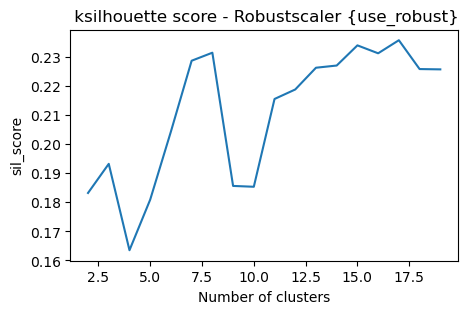

In [ ]:
plt.figure(figsize=(5,3))
plt.plot(kclusters, ksil_scores)
plt.ylabel("sil_score")
plt.xlabel("Number of clusters")
plt.title(" ksilhouette score - Robustscaler ")

Text(0.5, 0, 'Number of clusters')

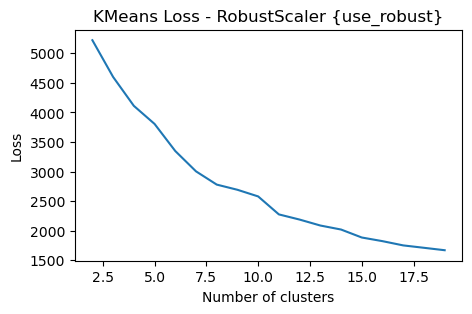

In [1043]:
plt.figure(figsize=(5,3))
plt.plot(kclusters, klosses)
plt.ylabel("Loss")
plt.title("KMeans Loss - RobustScaler {use_robust}")
plt.xlabel("Number of clusters")

In [1044]:
aclusters = []
alabels = pd.DataFrame()
asil_scores = []
alosses = []

for k in range(2, 20):
    cluster = str(k)
    aclusters.append(k)
    amodel = AgglomerativeClustering(n_clusters=k)
    label = amodel.fit_predict(X_scaled)
    alabels[cluster] = label
    asil_scores.append(silhouette_score(X_scaled, label))
    #alosses.append(amodel.inertia_)

Text(0.5, 1.0, 'asilhouette score - RobustScaler {use_robust}')

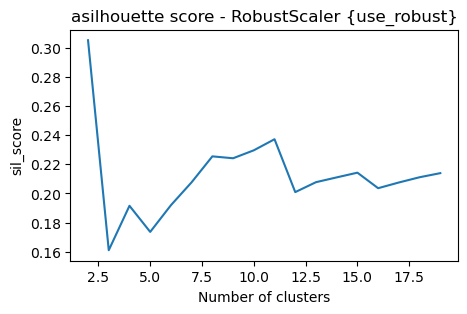

In [1045]:
plt.figure(figsize=(5,3))
plt.plot(aclusters, asil_scores)
plt.ylabel("sil_score")
plt.xlabel("Number of clusters")
plt.title("asilhouette score - RobustScaler {use_robust}")

In [1046]:
#cluster 5 oder 7
kbest_cluster = str(8)
X["labels"] = klabels[kbest_cluster]
X

,avg_charging_time,avg_blocking_time,weekday_ratio,site_one_ratio,avg_connection_hour_sin,avg_connection_hour_cos,sessions_per_week,is_single_user,labels
0,74.000000,10.000000,1.00,0.0,-0.258819,-0.965926,1.000000,True,6
1,255.851064,143.382979,1.00,0.0,0.610461,-0.619514,0.522024,False,3
2,419.000000,78.000000,0.00,0.0,0.707107,-0.707107,1.000000,True,4
3,129.000000,84.000000,0.00,0.0,-0.965926,-0.258819,1.000000,True,4
4,308.250000,74.250000,0.25,0.0,-0.634765,-0.245891,0.401433,False,4
...,...,...,...,...,...,...,...,...,...
792,37.000000,0.000000,1.00,0.0,-0.965926,-0.258819,1.000000,True,6
793,134.750000,168.750000,1.00,1.0,0.824469,-0.470916,2.569970,False,1
794,278.000000,208.000000,1.00,1.0,0.965926,-0.258819,1.273588,False,5
795,126.000000,343.000000,1.00,1.0,0.866025,-0.500000,1.000000,True,5


In [1047]:
def sincos_to_hour(sin_val, cos_val):
    angle = np.arctan2(sin_val, cos_val)
    hour = (angle * 24 / (2 * np.pi)) % 24
    return hour

X["avg_connection_hour"] = sincos_to_hour(X["avg_connection_hour_sin"], X["avg_connection_hour_cos"])
X = X.drop(["avg_connection_hour_sin", "avg_connection_hour_cos"], axis=1)

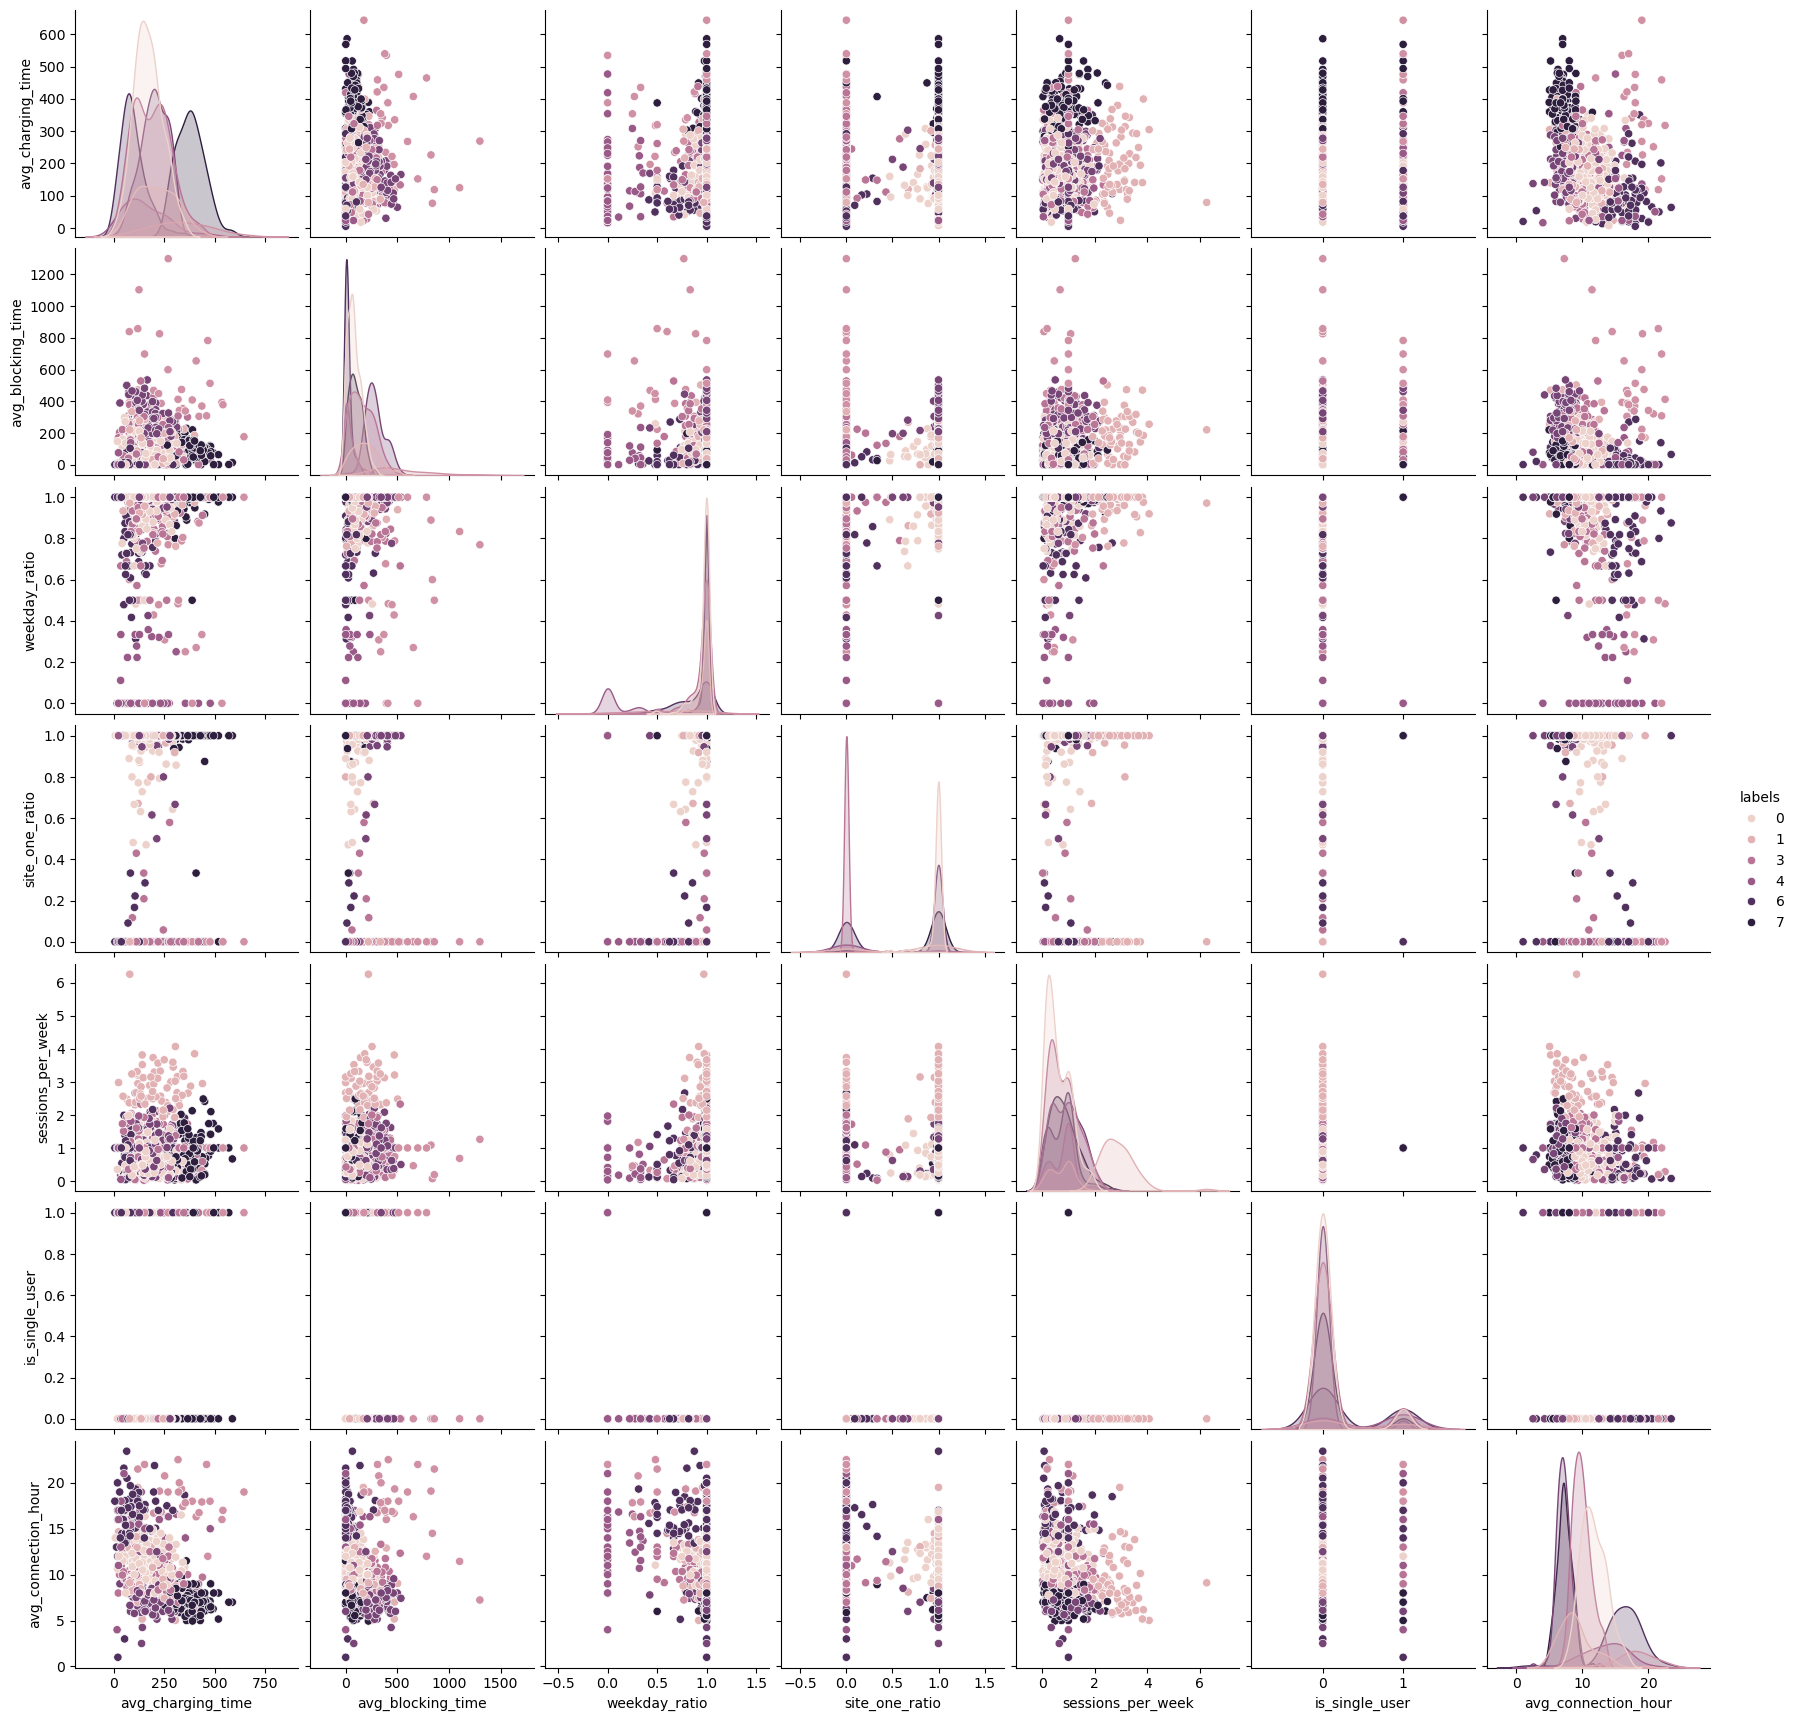

In [1048]:
sns.pairplot(X, hue="labels")
#plt.set_title("Pairplot for Agglomerative K="+kbest_cluster)
plt.show()

In [1034]:
#X[X["labels"] == 0].describe()

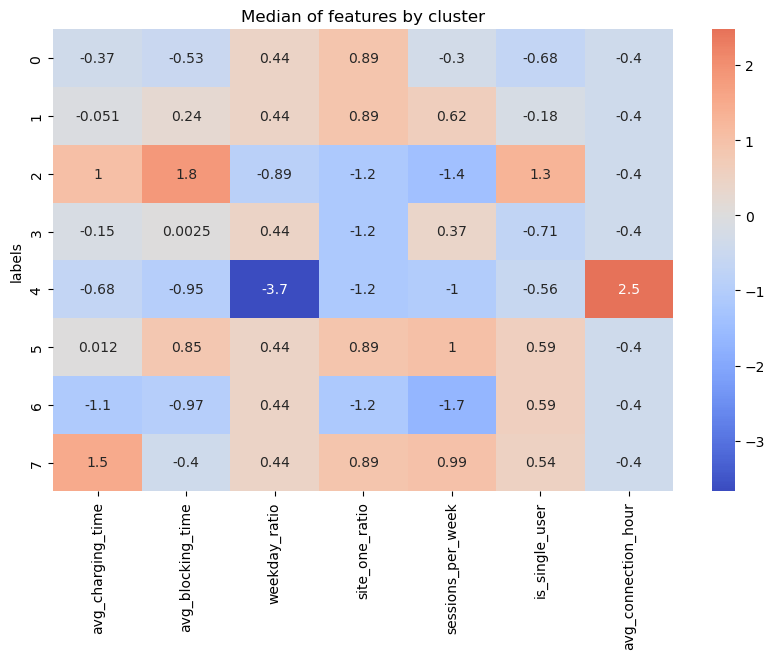

In [1049]:
X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=X.columns,   # wichtig!
    index=X.index
)

X_scaled_df["labels"] = X["labels"]
features = X_scaled_df.columns.drop("labels")
cluster_medians = X_scaled_df.groupby("labels")[features].median()

plt.figure(figsize=(10, 6))
sns.heatmap(
    cluster_medians,
    annot=True,
    cmap="coolwarm",
    center=0
)
plt.title("Median of features by cluster")
plt.show()

Agglomerative with 7 clusters:
- Cluster 0: charge very regularly and quik, efficient, early in the day - pendler, ideal user for infrastructure
- Cluster 1: charge mid often and a little longer, have the time and charge later the day - regular user who have chargingstation 1 close to the workplace or home, potentially blocking but planbar
- Cluster 2: all values relatively close to zero, charges at station 1 - average user with no strong pattern, good as reference group
- Cluster 3: average user who charges at station 2, has a little more time than cluster 2 users
- cluster 4: irregular weekend user who charge later of the day and have very long charging and blocking time - inefficient blockers, problematic, hard to calculate
- cluster 5: users who charge only on the weekwend, who are efficient and charge quickly
- cluster 6: user with short charging times who leave right after charging and charge irregulary - hobby driver, little routine



In [1036]:
X["labels"].value_counts().sort_index()

labels
0    185
1     38
2    111
3     35
4     72
5     64
6     47
7     68
8    177
Name: count, dtype: int64

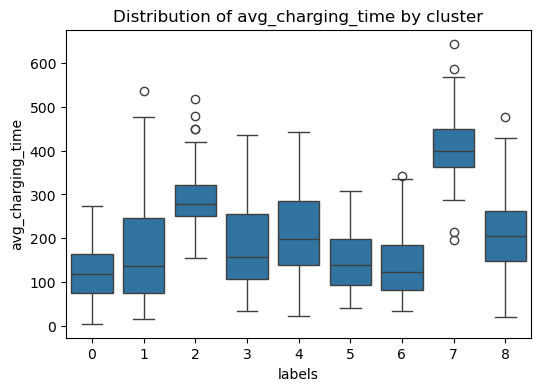

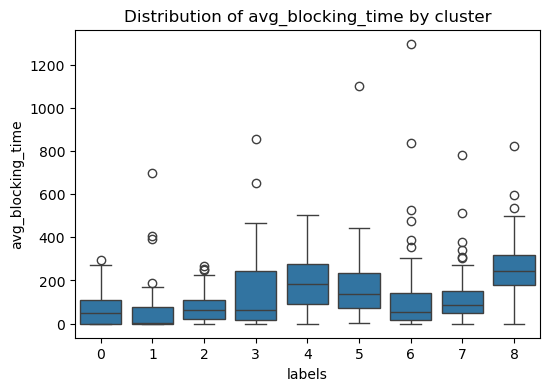

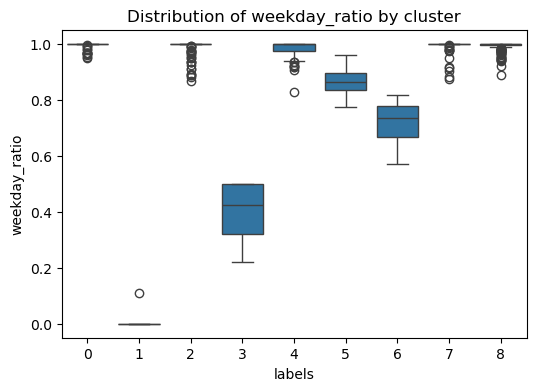

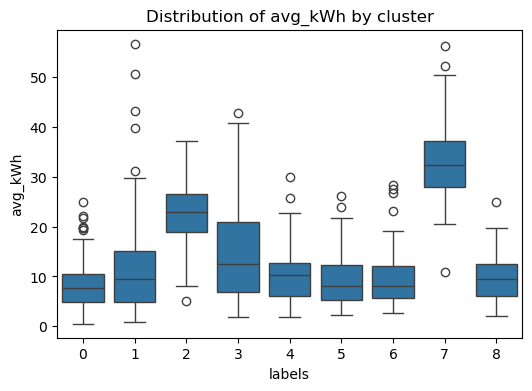

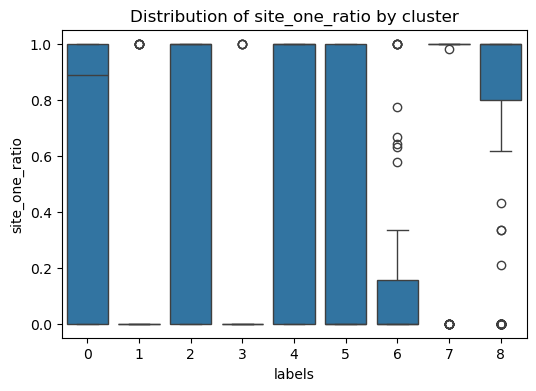

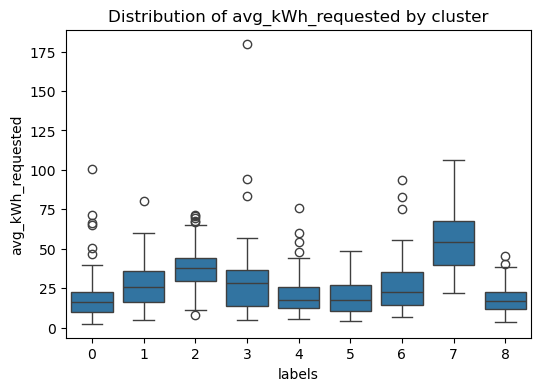

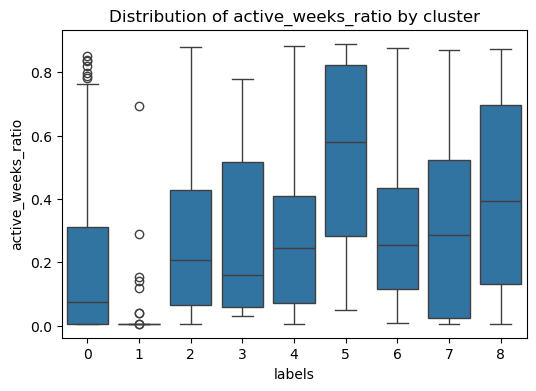

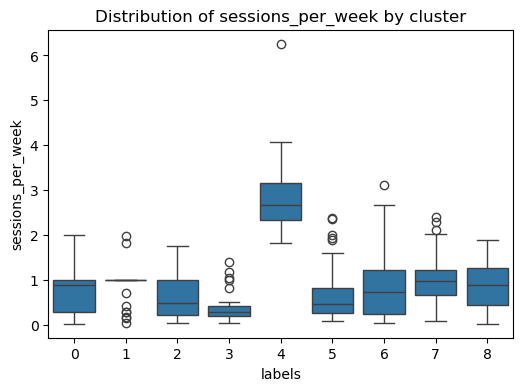

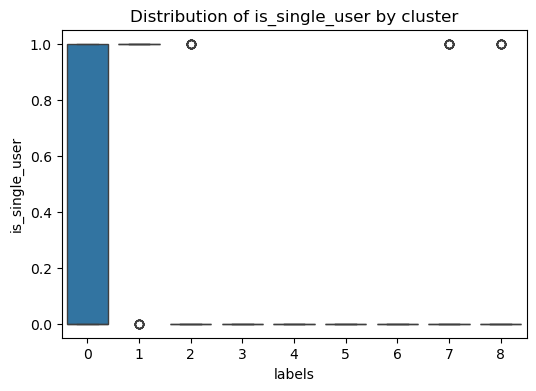

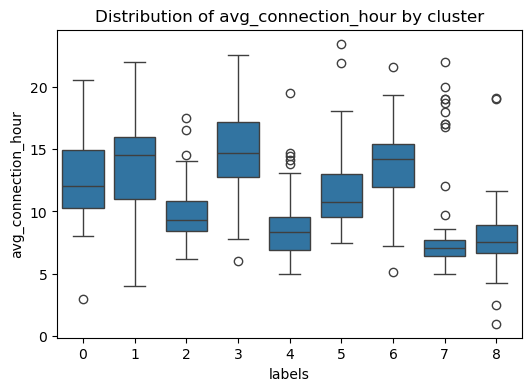

In [1037]:
for f in features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x="labels", y=f, data=X)
    plt.title(f"Distribution of {f} by cluster")
    plt.show()

In [1038]:
featuresS = X_scaled.columns

X_long = X.melt(
    id_vars="labels",
    value_vars=featuresS,
    var_name="feature",
    value_name="value"
)

AttributeError: 'numpy.ndarray' object has no attribute 'columns'

In [ ]:
g = sns.catplot(
    data=X_long,
    x="feature",
    y="value",
    col="labels",
    kind="box",
    col_wrap=3,
    sharey=False,
    height=4,
    aspect=1.2
)

g.set_xticklabels(rotation=45, ha="right")
g.set_titles("Cluster {col_name}")
plt.show()